In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seaborn import histplot,heatmap,violinplot,kdeplot
df_test=pd.read_csv('../data/car_testA_0110.csv')
df_train=pd.read_csv('../data/car_train_0110.csv')
df_test.columns
df_train.columns

Index(['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType',
       'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode',
       'seller', 'offerType', 'creatDate', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4',
       'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13',
       'v_14', 'v_15', 'v_16', 'v_17', 'v_18', 'v_19', 'v_20', 'v_21', 'v_22',
       'v_23'],
      dtype='object')

Index(['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType',
       'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode',
       'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1', 'v_2', 'v_3',
       'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12',
       'v_13', 'v_14', 'v_15', 'v_16', 'v_17', 'v_18', 'v_19', 'v_20', 'v_21',
       'v_22', 'v_23'],
      dtype='object')

In [2]:
#修改列名
df_train.columns=['交易ID','交易名称','汽车注册日期','车型编码','汽车品牌','车身类型','燃油类型','变速箱','发动机功率','汽车已行驶公里','汽车有尚未修复的损坏','地区编码','销售方','报价类型','汽车上线时间','二手车交易价格','v_O','v_1','v_ 2','v_3','v_4','v_5','v_6','v_7','v_8','v_9','v_10','v_11','v_12','v_13','v_14','v_15','v_16','v_17','v_18','v_19','v_20','v_21','v_22','v_23']

In [3]:
#修改列名
df_test.columns=['交易ID','交易名称','汽车注册日期','车型编码','汽车品牌','车身类型','燃油类型','变速箱','发动机功率','汽车已行驶公里','汽车有尚未修复的损坏','地区编码','销售方','报价类型','汽车上线时间','v_O','v_1','v_ 2','v_3','v_4','v_5','v_6','v_7','v_8','v_9','v_10','v_11','v_12','v_13','v_14','v_15','v_16','v_17','v_18','v_19','v_20','v_21','v_22','v_23']
df_test.columns

Index(['交易ID', '交易名称', '汽车注册日期', '车型编码', '汽车品牌', '车身类型', '燃油类型', '变速箱',
       '发动机功率', '汽车已行驶公里', '汽车有尚未修复的损坏', '地区编码', '销售方', '报价类型', '汽车上线时间',
       'v_O', 'v_1', 'v_ 2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9',
       'v_10', 'v_11', 'v_12', 'v_13', 'v_14', 'v_15', 'v_16', 'v_17', 'v_18',
       'v_19', 'v_20', 'v_21', 'v_22', 'v_23'],
      dtype='object')

In [4]:
df_train.dtypes.rename('类型').to_frame().iloc[:16].assign(取值=df_train.nunique(),
缺失=(df_train.isnull()|df_train.isna()|df_train.apply(lambda x:x=='')).sum(),
总数=df_train.shape[0]
).eval('缺失率=缺失/总数*100')

,类型,取值,缺失,总数,缺失率
交易ID,int64,250000,0,250000,0.0000
交易名称,int64,164312,0,250000,0.0000
汽车注册日期,int64,7537,0,250000,0.0000
车型编码,float64,251,0,250000,0.0000
汽车品牌,int64,40,0,250000,0.0000
车身类型,float64,8,25380,250000,10.1520
燃油类型,float64,7,22490,250000,8.9960
变速箱,float64,2,13513,250000,5.4052
发动机功率,int64,703,0,250000,0.0000
汽车已行驶公里,float64,13,0,250000,0.0000


交易ID             Axes(0.125,0.712609;0.065678x0.167391)
交易名称          Axes(0.203814,0.712609;0.065678x0.167391)
汽车注册日期        Axes(0.282627,0.712609;0.065678x0.167391)
车型编码          Axes(0.361441,0.712609;0.065678x0.167391)
汽车品牌          Axes(0.440254,0.712609;0.065678x0.167391)
车身类型          Axes(0.519068,0.712609;0.065678x0.167391)
燃油类型          Axes(0.597881,0.712609;0.065678x0.167391)
变速箱           Axes(0.676695,0.712609;0.065678x0.167391)
发动机功率         Axes(0.755508,0.712609;0.065678x0.167391)
汽车已行驶公里       Axes(0.834322,0.712609;0.065678x0.167391)
汽车有尚未修复的损坏       Axes(0.125,0.511739;0.065678x0.167391)
地区编码          Axes(0.203814,0.511739;0.065678x0.167391)
销售方           Axes(0.282627,0.511739;0.065678x0.167391)
报价类型          Axes(0.361441,0.511739;0.065678x0.167391)
汽车上线时间        Axes(0.440254,0.511739;0.065678x0.167391)
二手车交易价格       Axes(0.519068,0.511739;0.065678x0.167391)
v_O           Axes(0.597881,0.511739;0.065678x0.167391)
v_1           Axes(0.676695,0.511739;0.065678x0.

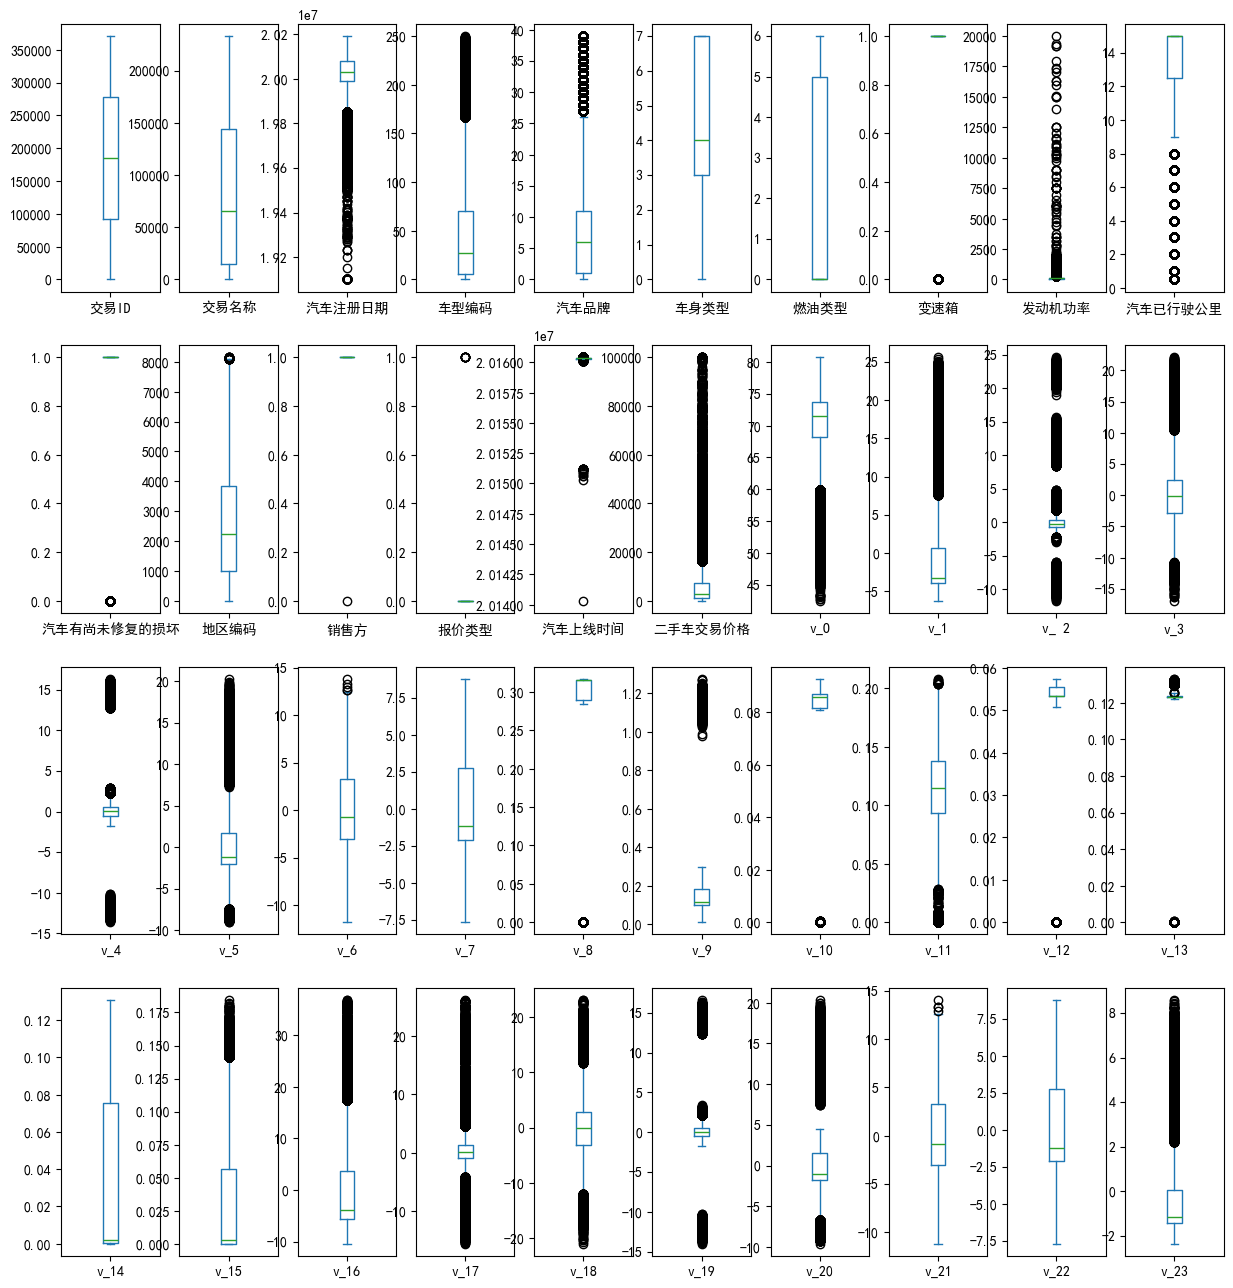

In [5]:
# 实现数据的异常值或离群点检测
df_train.plot.box(subplots=True, layout=(4,10),figsize=(15 ,16))

In [ ]:
#创建并保存二手车价格高低的标签(,
df_train=df_train.assign(
    价格标签=pd.cut(
    df_train.二手车交易价格,
    bins=[0,df_train.二手车交易价格.mean(),df_train.二手车交易价格.max()+1],
    labels=[0,1])
)
df_train

,交易ID,交易名称,汽车注册日期,车型编码,汽车品牌,车身类型,燃油类型,变速箱,发动机功率,汽车已行驶公里,...,v_15,v_16,v_17,v_18,v_19,v_20,v_21,v_22,v_23,价格标签
0,134890,734,20160002,13.0,9,NaN,0.0,1.0,0,15.0,...,0.000000,18.763832,-1.512063,-1.008718,-12.100623,-0.947052,9.077297,0.581214,3.945923,0
1,306648,196973,20080307,72.0,9,7.0,5.0,1.0,173,15.0,...,0.122335,-5.685612,-0.489963,-2.223693,-0.226865,-0.658246,-3.949621,4.593618,-1.145653,0
2,340675,25347,20020312,18.0,12,3.0,0.0,1.0,50,12.5,...,0.003345,-3.295700,1.816499,3.554439,-0.683675,0.971495,2.625318,-0.851922,-1.246135,0
3,57332,5382,20000611,38.0,8,7.0,0.0,1.0,54,15.0,...,0.000000,-3.405521,1.497826,4.782636,0.039101,1.227646,3.040629,-0.801854,-1.251894,0
4,265235,173174,20030109,87.0,0,5.0,5.0,1.0,131,3.0,...,0.001655,-4.475429,0.124138,1.364567,-0.319848,-1.131568,-3.303424,-1.998466,-1.279368,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,10556,9332,20170003,13.0,9,NaN,NaN,1.0,58,15.0,...,0.001447,11.782508,20.402576,-2.722772,0.462388,-4.429385,7.883413,0.698405,-1.082013,0
249996,146710,102110,20030511,29.0,17,3.0,0.0,0.0,61,15.0,...,0.002342,-2.988272,1.500532,3.502201,-0.761715,-2.484556,-2.532968,-0.940266,-1.106426,0
249997,116066,82802,20130312,124.0,16,6.0,0.0,1.0,122,3.0,...,0.100760,-6.939560,-1.144959,-5.337949,0.896026,-0.592565,-3.872725,2.135984,3.807554,1
249998,90082,65971,20121212,111.0,4,7.0,5.0,0.0,184,9.0,...,0.008251,-7.222167,-1.383696,-5.402794,-0.409451,-1.891556,-3.104789,-3.777374,3.186218,1


In [7]:
df_train.to_csv('../data/new_car_train.csv',index=False)
df_test.to_csv('../data/new_car_test.csv',index=False)

<Axes: title={'center': '二手车交易价格箱形图'}>

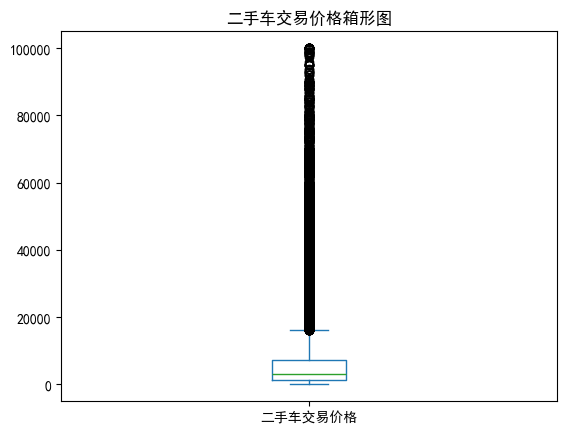

<Axes: ylabel='Frequency'>

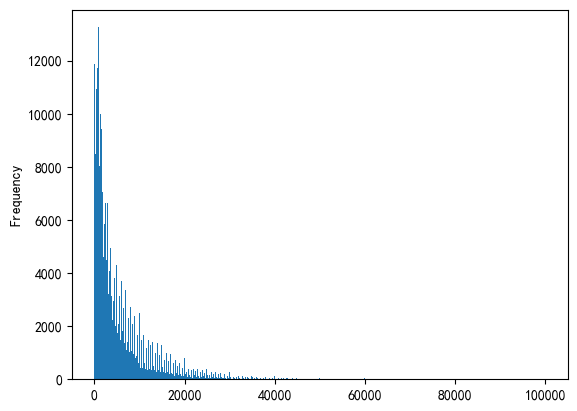

In [ ]:
#实现“成交价格的数据分析
# 利用直方图、箱型图实现成交价格标签的分布统计,其中bins设置为500
df_train.二手车交易价格.plot.box(title='二手车交易价格箱形图')
plt.show()
df_train.二手车交易价格.plot.hist(bins=500)


<Axes: ylabel='count'>

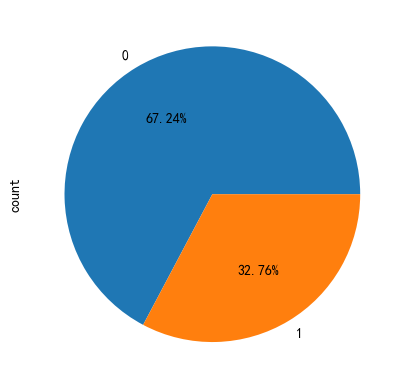

In [9]:
# 利用饼图实现成交价格标签的分布统计
df_train.价格标签.value_counts().plot.pie(autopct='%.2f%%')
plt.show()

<Axes: ylabel='Frequency'>

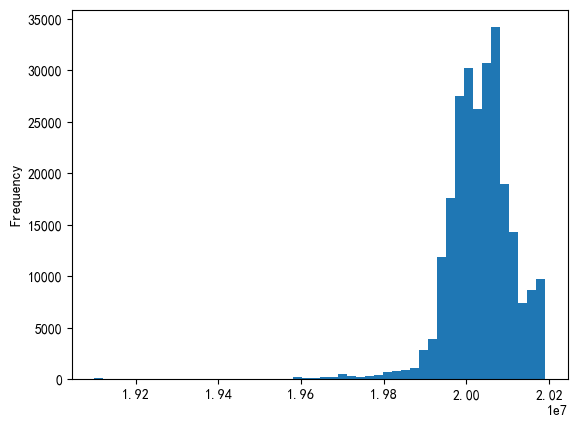

In [10]:
#实现汽车注册日期的分布统计
df_train.汽车注册日期.plot.hist(bins=50)

<Axes: xlabel='汽车注册日期', ylabel='Count'>

<Axes: xlabel='汽车注册日期', ylabel='Count'>

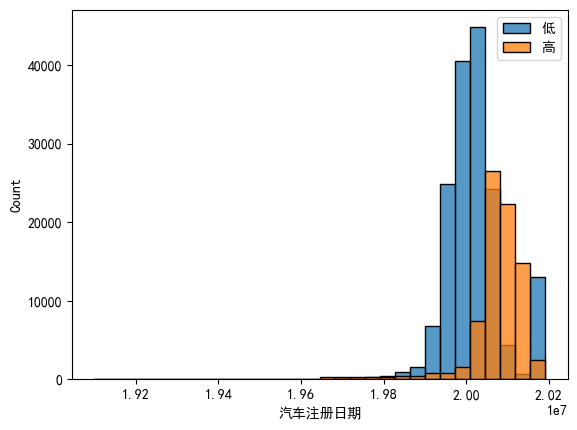

In [11]:
#不同价格标签下的汽车注册日期分布
histplot(df_train[df_train.价格标签==0],x='汽车注册日期',label='低',bins=30)
histplot(df_train[df_train.价格标签==1],x='汽车注册日期',label='高',bins=30)
plt.legend()

<Axes: xlabel='汽车注册日期', ylabel='Density'>

<Axes: xlabel='汽车注册日期', ylabel='Density'>

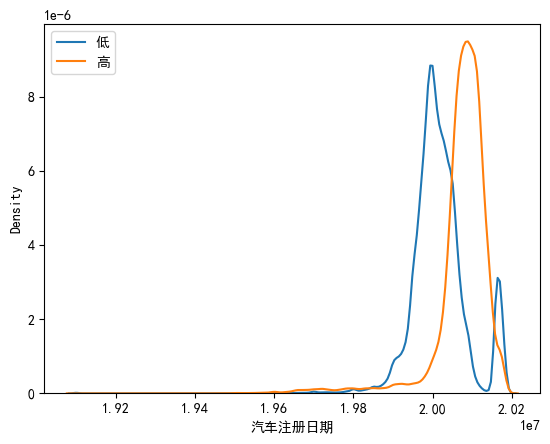

In [12]:
# 不同价格标签下的汽车注册日期分布
kdeplot(df_train[df_train.价格标签==0],x='汽车注册日期',label='低')
kdeplot(df_train[df_train.价格标签==1],x='汽车注册日期',label='高')
plt.legend()

<Axes: xlabel='汽车上线时间'>

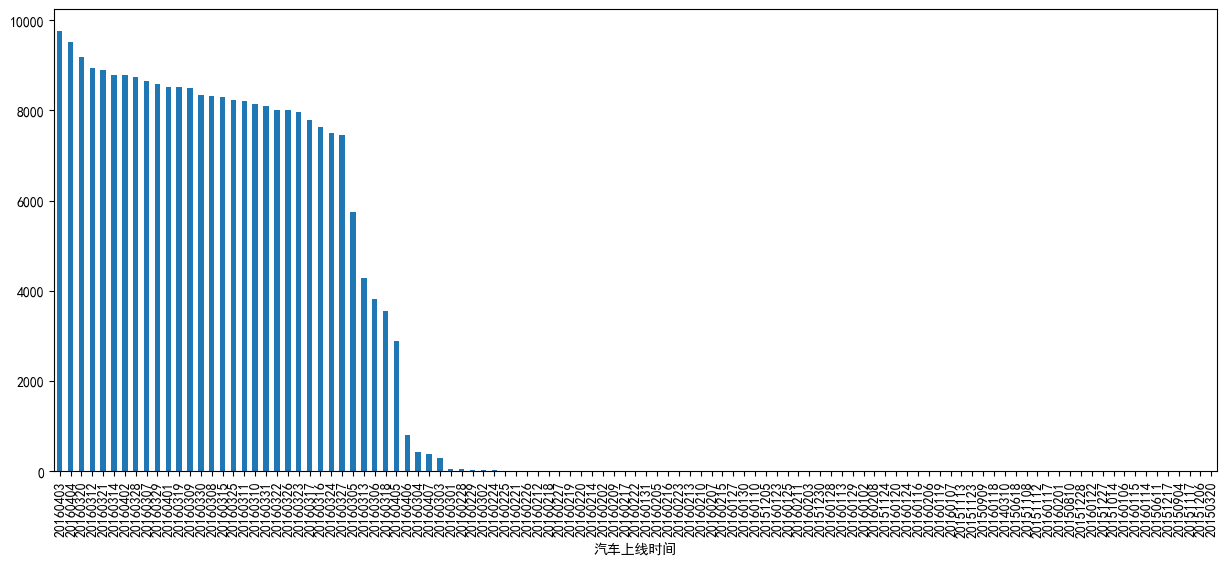

In [13]:
#实现汽车上线时间的分布统计
df_train.汽车上线时间.value_counts().plot.bar(figsize=(15,6))

<Axes: xlabel='汽车上线时间', ylabel='Count'>

<Axes: xlabel='汽车上线时间', ylabel='Count'>

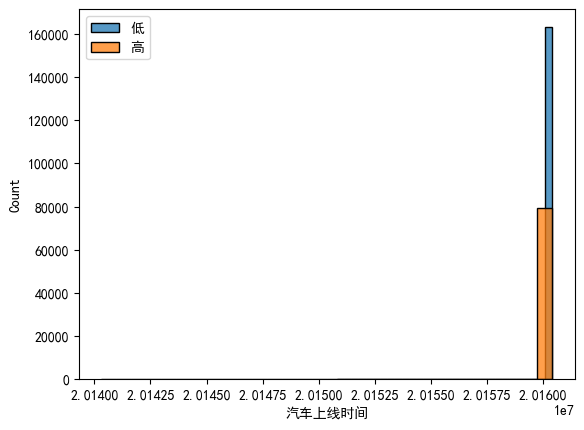

In [14]:
#不同价格标签下的汽车上线时间分布
histplot(df_train[df_train.价格标签==0],x='汽车上线时间',label='低',bins=30)
histplot(df_train[df_train.价格标签==1],x='汽车上线时间',label='高',bins=30)
plt.legend()

<Axes: xlabel='汽车上线时间', ylabel='Density'>

<Axes: xlabel='汽车上线时间', ylabel='Density'>

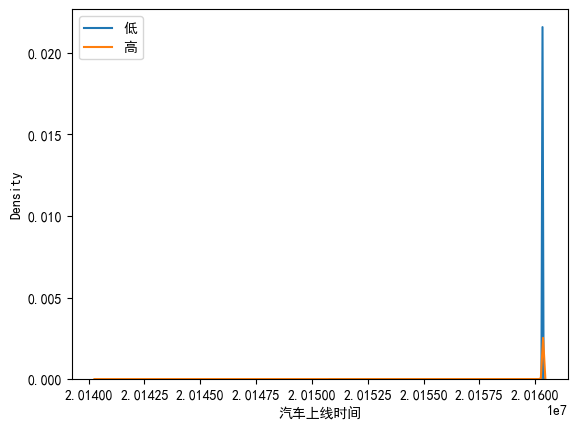

In [15]:
#不同价格标签下的汽车上线时间分布
kdeplot(df_train[df_train.价格标签==0],x='汽车上线时间',label='低')
kdeplot(df_train[df_train.价格标签==1],x='汽车上线时间',label='高')
plt.legend()


<Axes: xlabel='车型编码'>

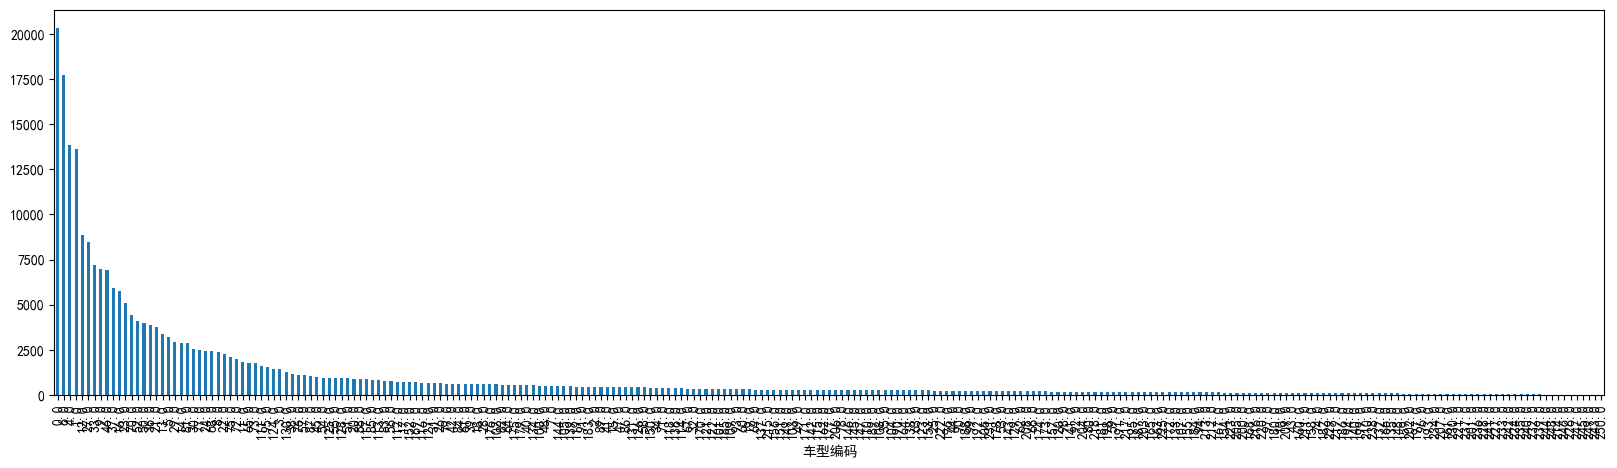

In [16]:
#实现车型编码的分布统计
df_train.车型编码.value_counts().plot.bar(figsize=(20 ,5))

C:\Users\123\AppData\Local\Temp\ipykernel_11096\1289429213.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train.groupby(['车型编码','价格标签']).size().to_frame().unstack()


<Axes: xlabel='车型编码'>

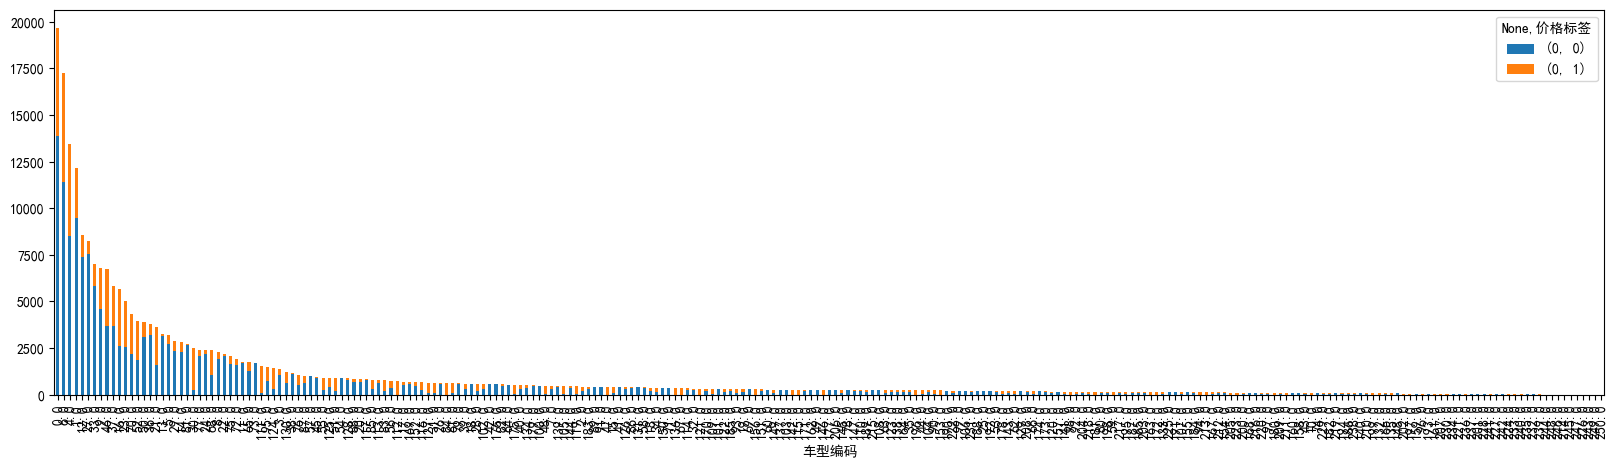

In [ ]:
#·不同价格标签下的车型编码分布
a=df_train.groupby(['车型编码','价格标签']).size().to_frame().unstack()
a.assign(合计=a.sum(axis=1)).sort_values('合计',ascending=False).iloc[:,:2].plot.bar(figsize=(20,5),stacked=True)

C:\Users\123\AppData\Local\Temp\ipykernel_11096\562565177.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train.groupby(['车型编码','价格标签']).size().to_frame().unstack()


<Axes: xlabel='车型编码'>

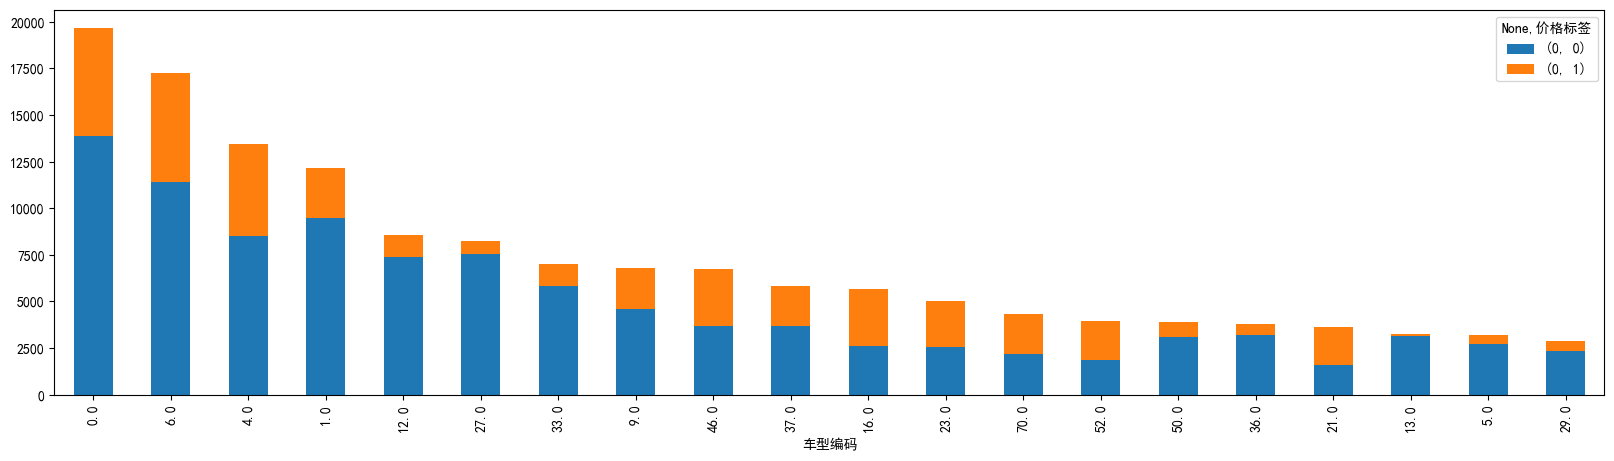

In [ ]:
#不同价格标签下的车型编码分布
a=df_train.groupby(['车型编码','价格标签']).size().to_frame().unstack()
a.assign(合计=a.sum(axis=1)).sort_values('合计',ascending=False).iloc[:,:2].head(20)\
    .plot.bar(figsize=(20,5),stacked=True)


<Axes: xlabel='汽车品牌'>

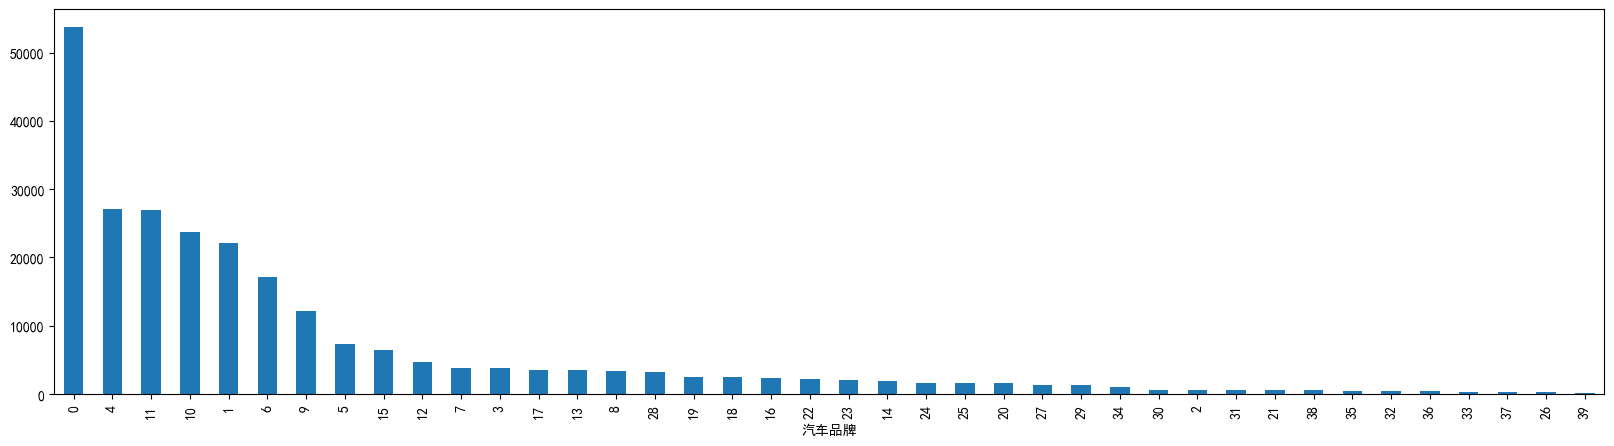

In [ ]:
# 实现汽车品牌的分布统计
df_train.汽车品牌.value_counts().plot.bar(figsize=(20, 5))

C:\Users\123\AppData\Local\Temp\ipykernel_11096\1288686960.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train.groupby(['汽车品牌','价格标签']).size().to_frame().unstack()


<Axes: xlabel='汽车品牌'>

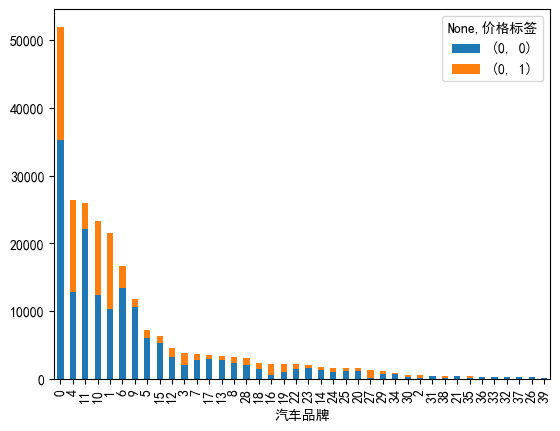

In [ ]:
a=df_train.groupby(['汽车品牌','价格标签']).size().to_frame().unstack()
a.assign(合计=a.sum(axis=1)).sort_values('合计',ascending=False).iloc[:,:2].plot.bar(stacked=True)

<Axes: xlabel='车身类型'>

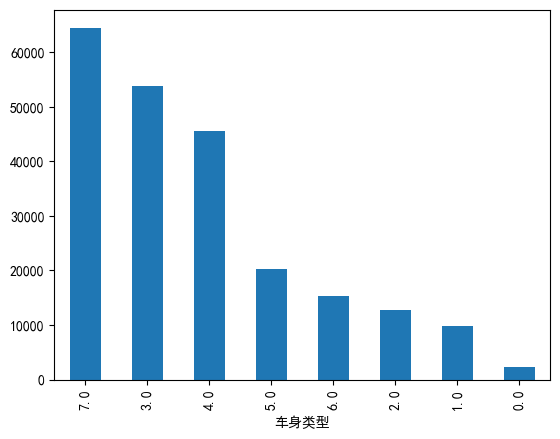

In [19]:
#·车身类型
df_train.车身类型.value_counts().plot.bar()

C:\Users\123\AppData\Local\Temp\ipykernel_21088\3147847195.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train.groupby(['车身类型','价格标签']).size().to_frame().unstack()


<Axes: xlabel='车身类型'>

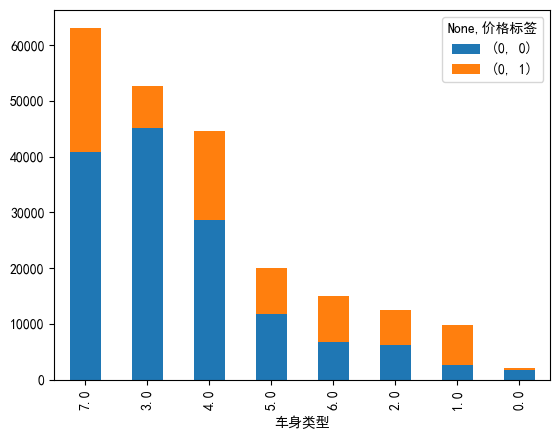

In [21]:

a=df_train.groupby(['车身类型','价格标签']).size().to_frame().unstack()
a.assign(合计=a.sum(axis=1)).sort_values('合计',ascending=False).iloc[:,:2].plot.bar(stacked=True)

<Axes: xlabel='燃油类型'>

C:\Users\123\AppData\Local\Temp\ipykernel_21088\438754361.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train.groupby(['燃油类型','价格标签']).size().to_frame().unstack()


<Axes: xlabel='燃油类型'>

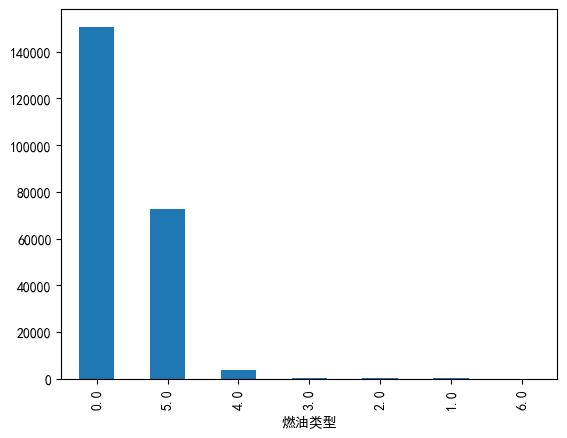

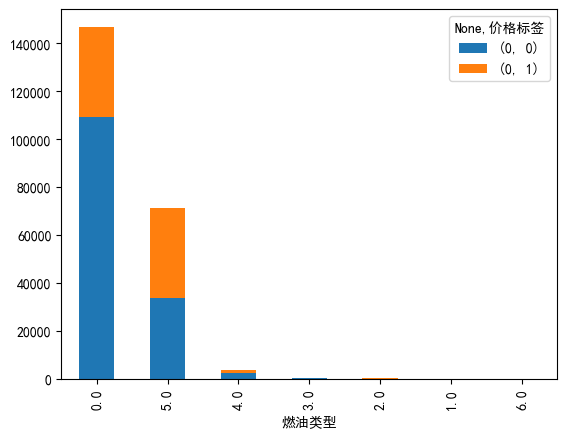

In [22]:
# 燃油类型
df_train.燃油类型.value_counts().plot.bar()
# 燃油类型
a=df_train.groupby(['燃油类型','价格标签']).size().to_frame().unstack()
a.assign(合计=a.sum(axis=1)).sort_values('合计',ascending=False).iloc[: ,:2].plot.bar(stacked=True)

<Axes: ylabel='count'>

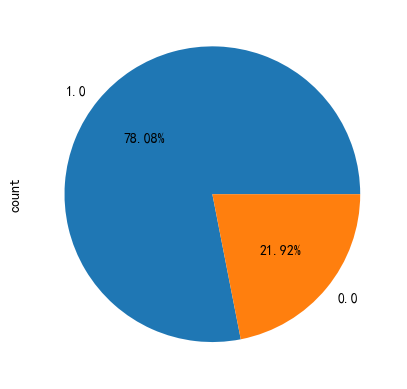

In [24]:
#实现变速箱的分布统计
df_train.变速箱.value_counts().plot.pie(autopct='%.2f%%')

C:\Users\123\AppData\Local\Temp\ipykernel_21088\2822102964.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train[['变速箱','价格标签','交易ID']].groupby(['变速箱','价格标签']).count()


交易ID
变速箱 价格标签        
0.0 0      21788
    1      29096
1.0 0     131147
    1      48839

<Axes: ylabel='交易ID'>

<Axes: ylabel='交易ID'>

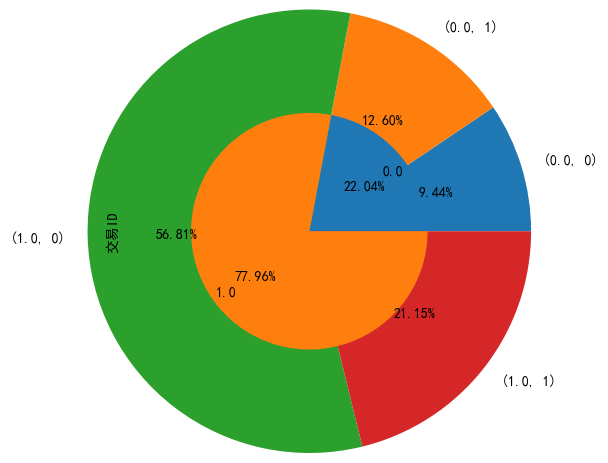

In [29]:
#不同价格标签下的变速箱分布
a=df_train[['变速箱','价格标签','交易ID']].groupby(['变速箱','价格标签']).count()
a
a.交易ID.plot.pie(autopct='%.2f%%',radius=1.5)
a.交易ID.groupby(level=0).sum().plot.pie(autopct='%.2f%%',radius=0.8,labeldistance=0.8)

<Axes: ylabel='count'>

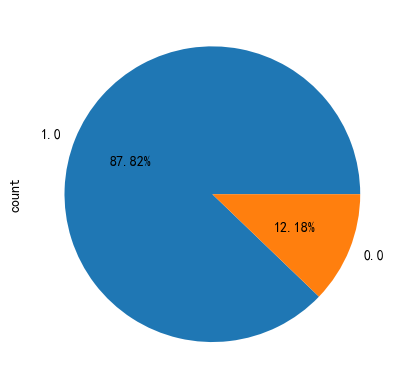

C:\Users\123\AppData\Local\Temp\ipykernel_21088\1976901618.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df_train[['汽车有尚未修复的损坏','价格标签','交易ID']].groupby(['汽车有尚未修复的损坏','价格标签']).count()


交易ID
汽车有尚未修复的损坏 价格标签        
0.0        0      21083
           1       2108
1.0        0     104293
           1      70258

<Axes: ylabel='交易ID'>

<Axes: ylabel='交易ID'>

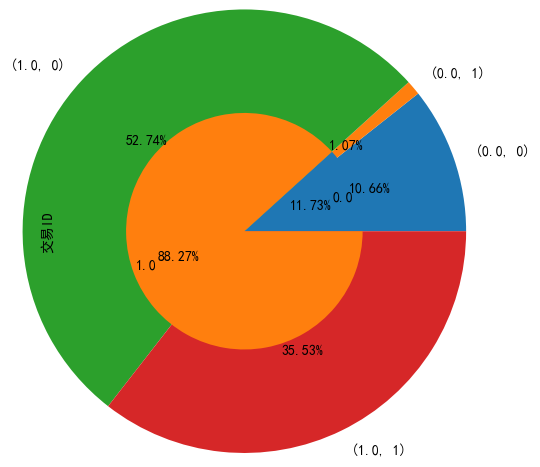

In [31]:
#汽车尚有未修复的损坏
df_train.汽车有尚未修复的损坏.value_counts().plot.pie(autopct='%.2f%%')
plt.show()
a=df_train[['汽车有尚未修复的损坏','价格标签','交易ID']].groupby(['汽车有尚未修复的损坏','价格标签']).count()
a
a.交易ID.plot.pie(autopct='%.2f%%',radius=1.5)
a.交易ID.groupby(level=0).sum().plot.pie(autopct='%.2f%%',radius=0.8,labeldistance=0.8)

<Axes: ylabel='count'>

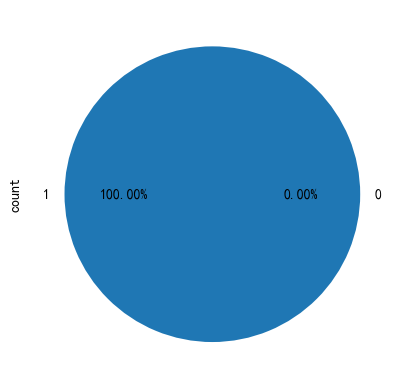

In [32]:
# 销售方
df_train.销售方.value_counts().plot.pie(autopct='%.2f%%')

<Axes: ylabel='count'>

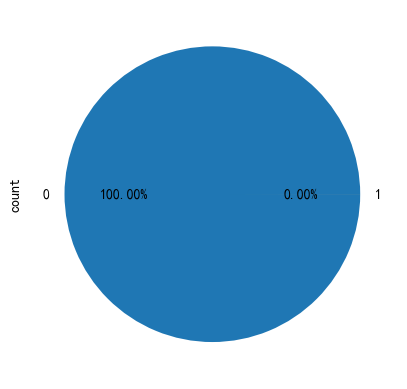

In [33]:
# 报价类型
df_train.报价类型.value_counts().plot.pie(autopct='%.2f%%')

<Axes: >

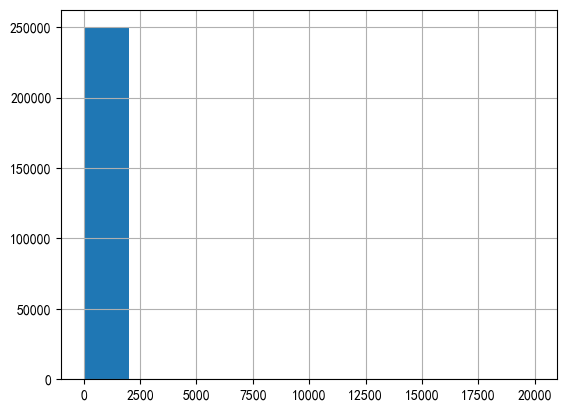

In [34]:
#实现发动机功率的分布统计
df_train.发动机功率.hist()

<Axes: xlabel='发动机功率', ylabel='Count'>

<Axes: xlabel='发动机功率', ylabel='Count'>

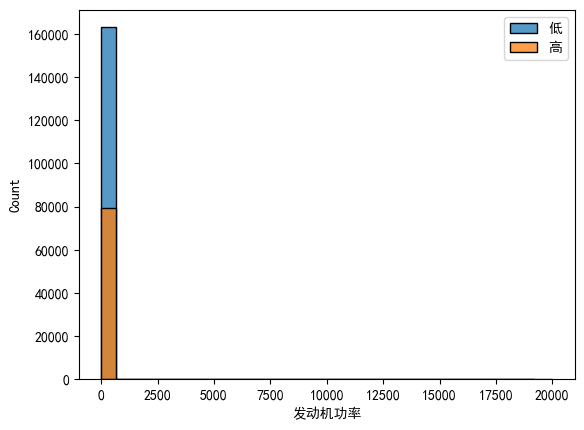

<Axes: xlabel='发动机功率', ylabel='Density'>

<Axes: xlabel='发动机功率', ylabel='Density'>

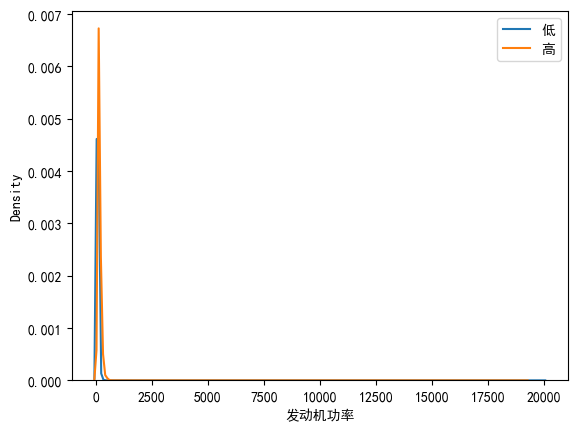

In [42]:
#不同价格标签工的发动机功率分布
histplot(df_train[df_train.价格标签==0],x='发动机功率',label='低',bins=30)
histplot(df_train[df_train.价格标签==1],x='发动机功率',label='高',bins=30)
plt.legend()
plt.show()
kdeplot(df_train[df_train.价格标签==0],x='发动机功率',label='低')
kdeplot(df_train[df_train.价格标签==1],x='发动机功率',label='高')
plt.legend()

<Axes: >

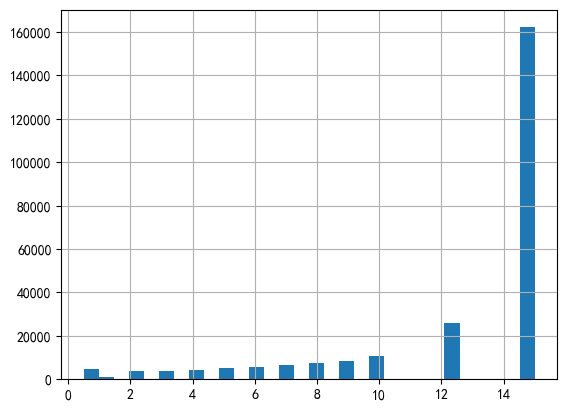

In [43]:
# 实现汽车已行驶公里的分布统计
df_train.汽车已行驶公里.hist(bins=30)

In [ ]:
# 不同价格标签下的汽车已行驶公里分布
histplot(df_train[df train.价格标冬==0],x='汽车已行驶公里'label='低'bins=30)
histplot(df_train[df_train.价格标多==11,x='汽车已行驶公里'label='高'bins=30)
plt.legend()
plt.show()
kdeplot(df_train[df_train.价格标签==0],x='汽车已行驶公里',label='低')
kdeplot(df_train[df_train.价格标签=1],x='汽车已行驶公里',label='高')
plt.legend()
